# Частина 2: Аналіз файлу 2017_jun_final.csv

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# щоб графіки відображались у ноутбуці
%matplotlib inline

sns.set_theme(style='ticks')

In [20]:
# Завантаження файлу
df = pd.read_csv('2017_jun_final.csv')
df.head()

,Мова програмування,Посада,Зарплата.в.місяць
0,Python,Junior,800
1,Java,Senior,3000
2,Python,Middle,2000
3,C++,Senior,3500
4,Python,Junior,900


In [21]:
# Розмір таблиці
df.shape

(6, 3)

In [22]:
# Типи стовпців
df.dtypes

,0
Мова програмування,object
Посада,object
Зарплата.в.місяць,int64


In [23]:
# Частка пропусків
missing_ratio = df.isnull().sum() / len(df)
missing_ratio

,0
Мова програмування,0.0
Посада,0.0
Зарплата.в.місяць,0.0


In [24]:
# Видалити всі стовпці з пропусками, крім "Мова програмування"
cols_to_keep = ['Мова програмування']
df_clean = df[cols_to_keep + [col for col in df.columns if df[col].isnull().sum() == 0 and col not in cols_to_keep]]

# Повторно рахуємо частку пропусків
df_clean.isnull().sum() / len(df_clean)

,0
Мова програмування,0.0
Посада,0.0
Зарплата.в.місяць,0.0


In [25]:
# Видалити всі рядки з пропусками
df_no_na = df.dropna()
df_no_na.shape

(6, 3)

In [26]:
# Таблиця тільки з Python
python_data = df_no_na[df_no_na['Мова програмування'] == 'Python']
python_data.shape

(3, 3)

In [27]:
# Групування за посадою
grouped = python_data.groupby('Посада')

In [28]:
# Мін і макс зарплати
salary_stats = grouped['Зарплата.в.місяць'].agg(['min', 'max'])
salary_stats

,min,max
Посада,,
Junior,800,900
Middle,2000,2000


In [29]:
# Функція середньої зарплати
def fill_avg_salary(group):
    return group['Зарплата.в.місяць'].mean()

salary_stats['avg'] = grouped.apply(fill_avg_salary)
salary_stats

/tmp/ipykernel_2459/1662333924.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  salary_stats['avg'] = grouped.apply(fill_avg_salary)


,min,max,avg
Посада,,,
Junior,800,900,850.0
Middle,2000,2000,2000.0


In [30]:
# Описова статистика
salary_stats['avg'].describe()

,avg
count,2.000000
mean,1425.000000
std,813.172798
min,850.000000
25%,1137.500000
50%,1425.000000
75%,1712.500000
max,2000.000000


In [31]:
# Збереження в CSV
salary_stats.to_csv('Hw2.2_result.csv')

## Візуалізація

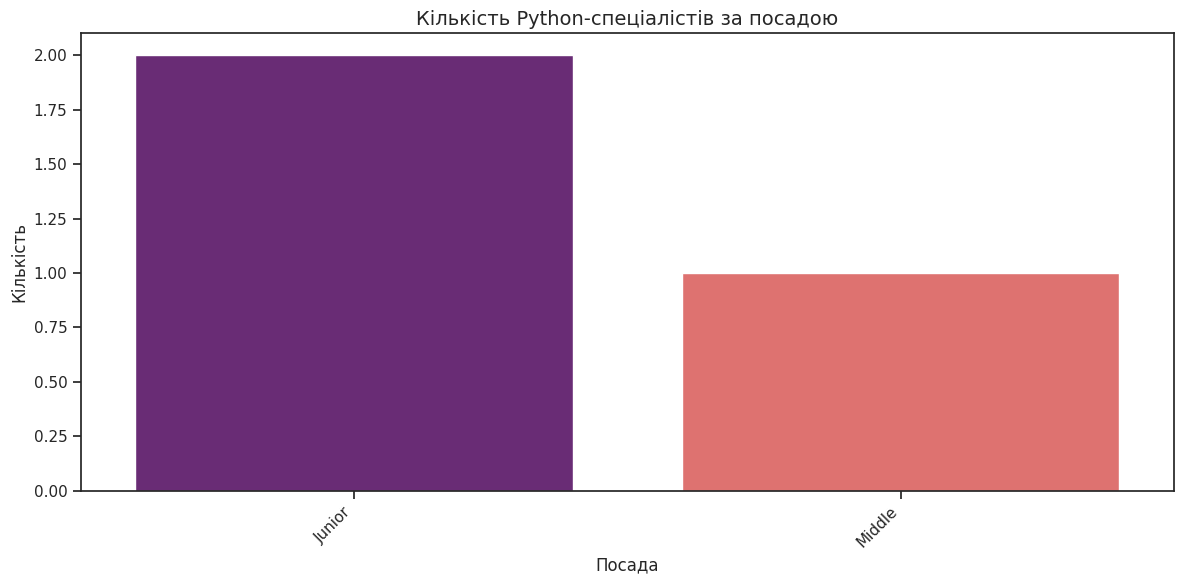

In [32]:
# 1. Кількість Python-спеціалістів за посадою
position_counts = python_data['Посада'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=position_counts.index, y=position_counts.values, hue=position_counts.index, dodge=False, palette='magma', legend=False)
plt.title('Кількість Python-спеціалістів за посадою', fontsize=14)
plt.xlabel('Посада')
plt.ylabel('Кількість')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

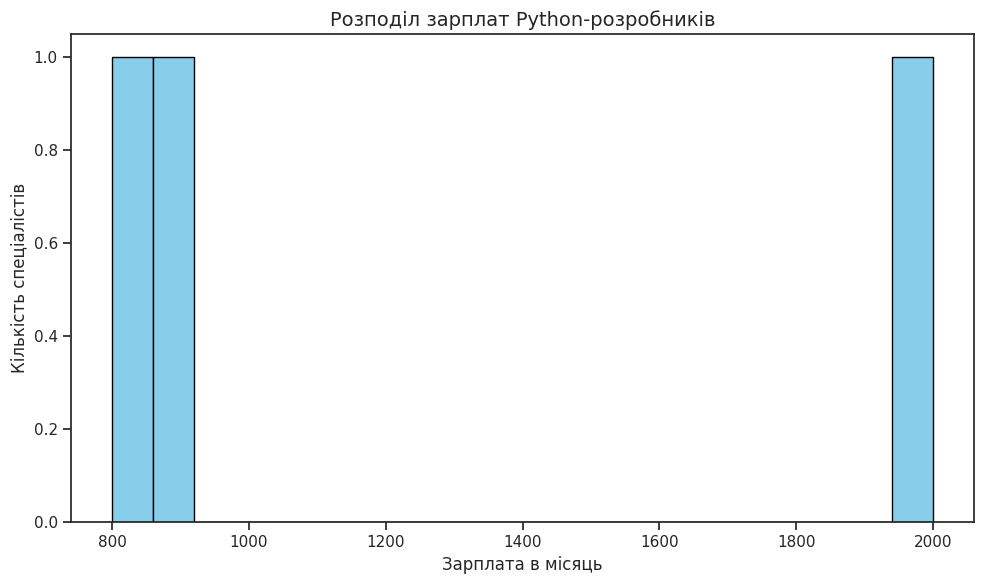

In [33]:
# 2. Розподіл зарплат Python-розробників
plt.figure(figsize=(10, 6))
plt.hist(python_data['Зарплата.в.місяць'], bins=20, color='skyblue', edgecolor='black')
plt.title('Розподіл зарплат Python-розробників', fontsize=14)
plt.xlabel('Зарплата в місяць')
plt.ylabel('Кількість спеціалістів')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2459/939085277.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=python_data, x='Посада', y='Зарплата.в.місяць', palette='Set3')


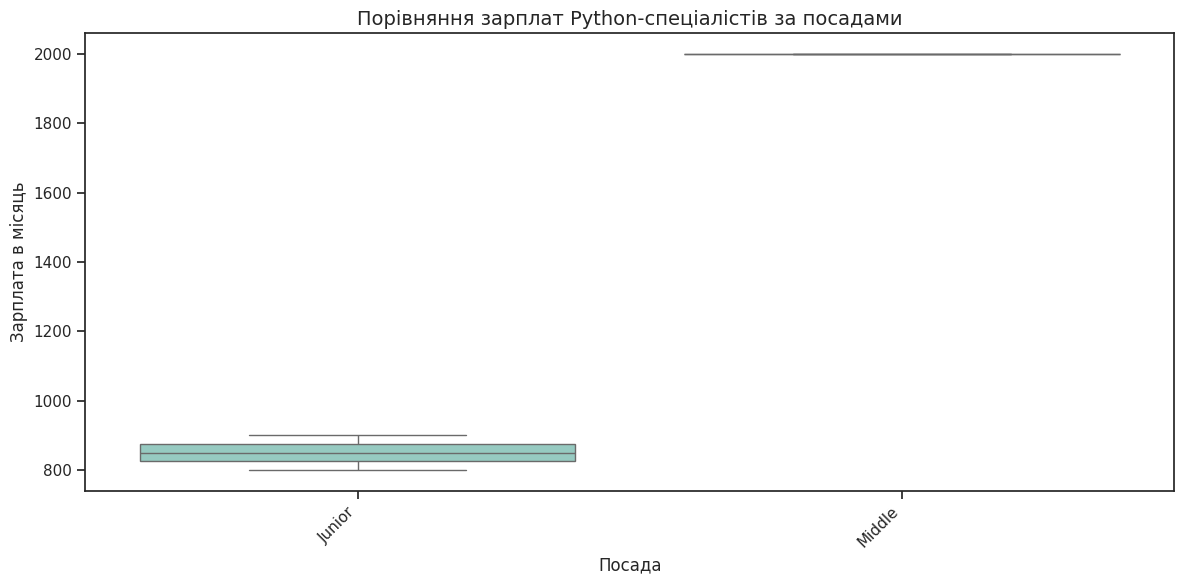

In [34]:
# 3. Boxplot зарплат за посадами
plt.figure(figsize=(12, 6))
sns.boxplot(data=python_data, x='Посада', y='Зарплата.в.місяць', palette='Set3')
plt.title('Порівняння зарплат Python-спеціалістів за посадами', fontsize=14)
plt.xlabel('Посада')
plt.ylabel('Зарплата в місяць')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

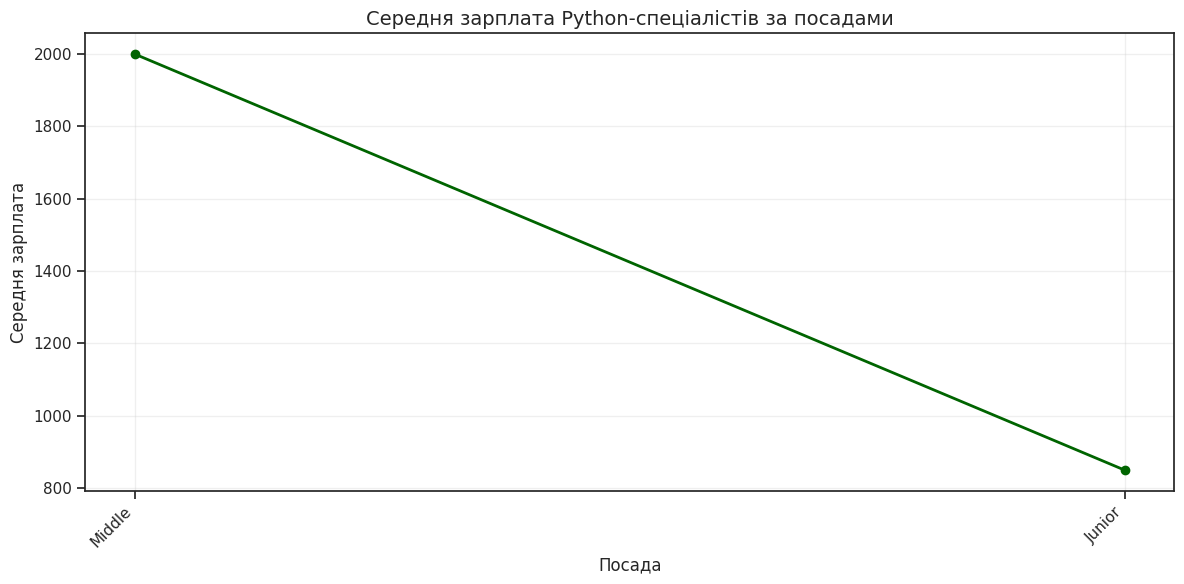

In [35]:
# 4. Середня зарплата за посадами
avg_salary_sorted = salary_stats.sort_values('avg', ascending=False)

plt.figure(figsize=(12, 6))
plt.plot(avg_salary_sorted.index, avg_salary_sorted['avg'], marker='o', linewidth=2, color='darkgreen')
plt.title('Середня зарплата Python-спеціалістів за посадами', fontsize=14)
plt.xlabel('Посада')
plt.ylabel('Середня зарплата')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

У датасеті відсутні пропуски, тому видалення стовпців не змінило структуру таблиці.